# AdaBoost and Gradient Boosting via Sklearn
* Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
* Objective: Familiarize yourself with standard boosting algorithms and the concept of learning rates.
* Task: Train an AdaBoostClassifier and a GradientBoostingClassifier on a structured dataset.
* Requirements:
  - Create a grid search (GridSearchCV) to tune the learning_rate and n_estimators.               - Plot the relationship between the number of estimators and the training/validation error.
  - Question to answer: At what point does the Gradient Boosting model start to overfit, and how does the learning rate affect this point?


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import log_loss


df = pd.read_csv("creditcard.csv")

X = df.drop(columns=['Class']) 
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

* Task: Train an AdaBoostClassifier and a GradientBoostingClassifier on a structured dataset.


In [5]:
param_grid_ada = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1.0]
}

grid_ada = GridSearchCV(AdaBoostClassifier(random_state=42), param_grid_ada, cv=3, scoring='f1', n_jobs=-1)
grid_ada.fit(X_train, y_train)

param_grid_gb = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=3, scoring='f1', n_jobs=-1)
grid_gb.fit(X_train, y_train)

print("Gradient Boosting :", grid_gb.best_params_)

print("AdaBoost :", grid_ada.best_params_)

Gradient Boosting : {'learning_rate': 0.1, 'n_estimators': 10}
AdaBoost : {'learning_rate': 1.0, 'n_estimators': 100}


  - Create a grid search (GridSearchCV) to tune the learning_rate and n_estimators.
  - Plot the relationship between the number of estimators and the training/validation error.


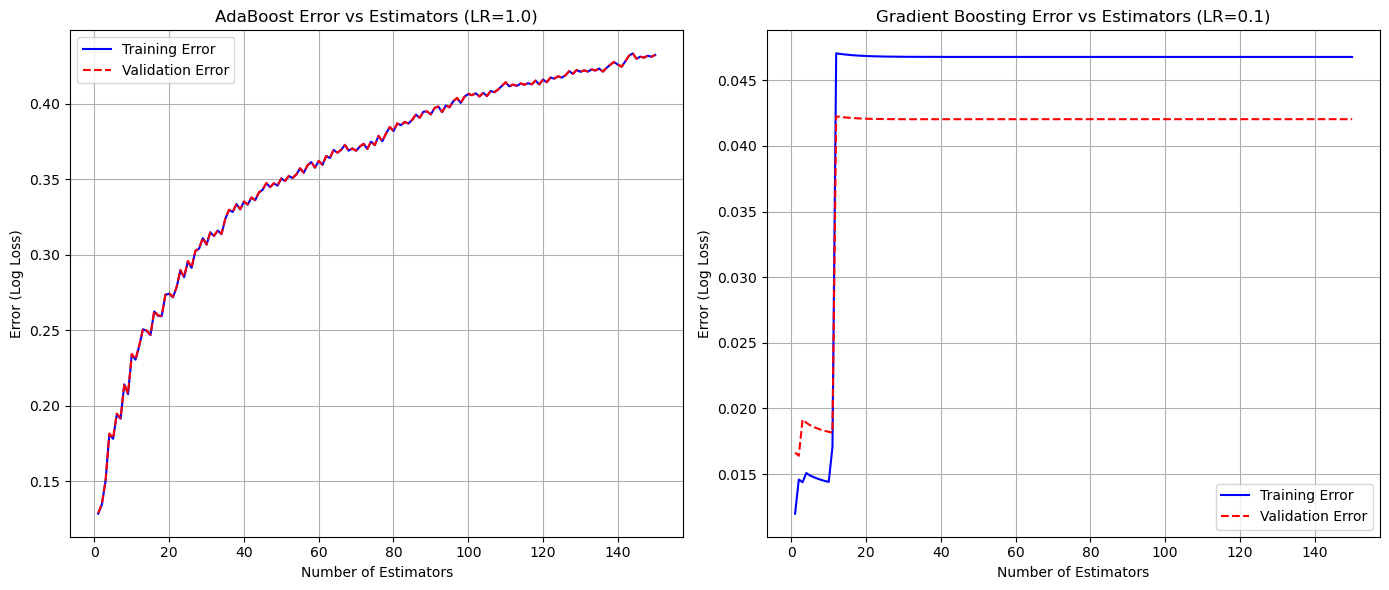

In [6]:
best_lr_ada = grid_ada.best_params_['learning_rate']
best_lr_gb = grid_gb.best_params_['learning_rate']

ada_model = AdaBoostClassifier(n_estimators=150, learning_rate=best_lr_ada, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=150, learning_rate=best_lr_gb, random_state=42)

ada_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

def get_staged_errors(model, X_tr, y_tr, X_val, y_val):
    train_errors = []
    val_errors = []
    
    for y_train_pred, y_val_pred in zip(model.staged_predict_proba(X_tr), model.staged_predict_proba(X_val)):
        train_errors.append(log_loss(y_tr, y_train_pred))
        val_errors.append(log_loss(y_val, y_val_pred))
        
    return train_errors, val_errors

ada_train_err, ada_val_err = get_staged_errors(ada_model, X_train, y_train, X_test, y_test)
gb_train_err, gb_val_err = get_staged_errors(gb_model, X_train, y_train, X_test, y_test)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(ada_train_err) + 1), ada_train_err, label='Training Error', color='blue')
plt.plot(range(1, len(ada_val_err) + 1), ada_val_err, label='Validation Error', color='red', linestyle='--')
plt.title(f'AdaBoost Error vs Estimators (LR={best_lr_ada})')
plt.xlabel('Number of Estimators')
plt.ylabel('Error (Log Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(gb_train_err) + 1), gb_train_err, label='Training Error', color='blue')
plt.plot(range(1, len(gb_val_err) + 1), gb_val_err, label='Validation Error', color='red', linestyle='--')
plt.title(f'Gradient Boosting Error vs Estimators (LR={best_lr_gb})')
plt.xlabel('Number of Estimators')
plt.ylabel('Error (Log Loss)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Extreme Gradient Boosting (XGBoost/LightGBM)
* Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
* Objective: Utilize industry-standard libraries to handle real-world challenges like class imbalance and early stopping.
* Task: Use the xgboost or lightgbm library on a highly imbalanced dataset (e.g., Credit Card Fraud Detection).
* Requirements:
  - Implement Early Stopping by using a dedicated validation set during the training loop to halt training when validation log-loss stops improving.
  - Handle the class imbalance using the scale_pos_weight parameter or by utilizing focal loss.
  - Use SHAP (SHapley Additive exPlanations) values to interpret the most important features driving the model's predictions.


In [1]:
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier

df = pd.read_csv("creditcard.csv")
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    early_stopping_rounds=10,
    eval_metric="logloss",
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.87      0.80      0.83        74

    accuracy                           1.00     42722
   macro avg       0.93      0.90      0.92     42722
weighted avg       1.00      1.00      1.00     42722

